In [1]:
from Configurations.imports import *
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()
iris.feature_names

In [6]:
iris_data = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [9]:
# train and test split of the data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
x_train, x_test = train_test_split(iris_data,test_size=0.20,random_state=43)
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

In [10]:
# reducing the dimensions
from sklearn.decomposition import PCA
decomposer = PCA(n_components=2)
x_train_d = decomposer.fit_transform(x_train_s)
x_test_d = decomposer.transform(x_test_s)

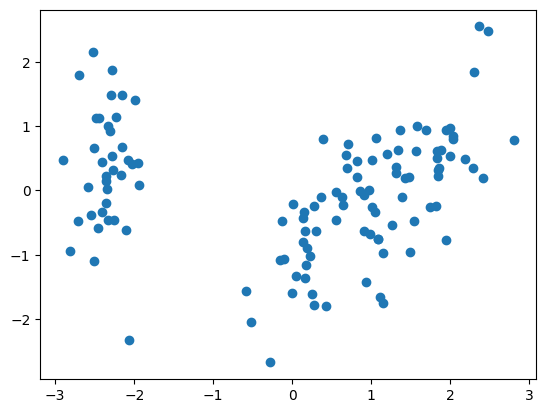

In [12]:
# viz 
plt.scatter(x_train_d[:,0],x_train_d[:,1])

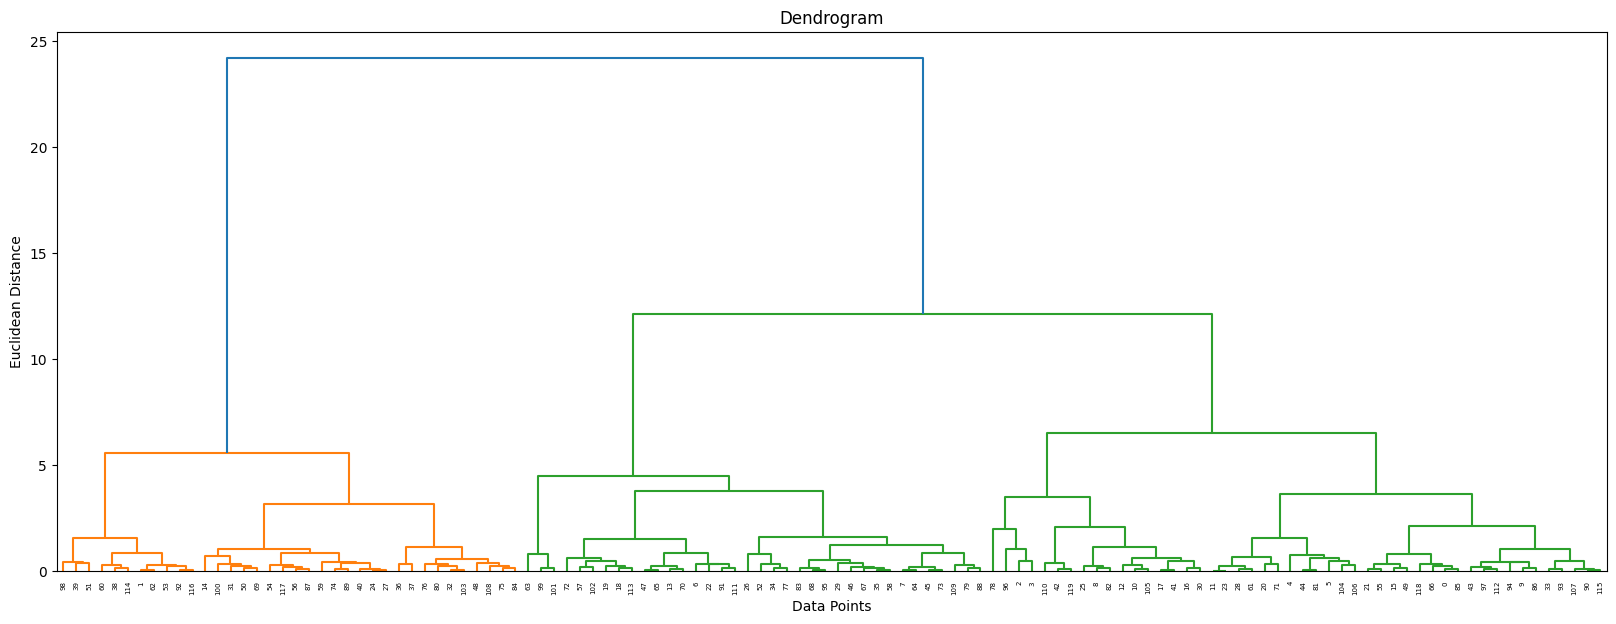

In [14]:
import scipy.cluster.hierarchy as sc
import matplotlib.pyplot as plt

plt.figure(figsize=(20,7))
plt.title("Dendrogram")

sc.dendrogram(sc.linkage(x_train_d, method="ward"))

plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

In [15]:
# clustering
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=2, metric="euclidean", linkage="ward")

cluster.fit(x_train_d)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [18]:
preds = cluster.fit_predict(x_train_d)

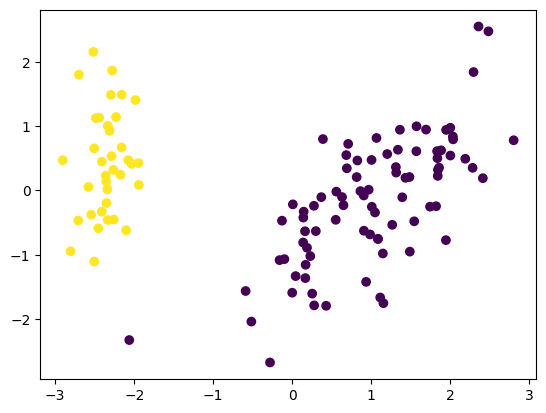

In [19]:
plt.scatter(x_train_d[:,0],x_train_d[:,1], c=preds)